In [69]:
import sys
import pandas as pd
import numpy as np
import torch

from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import Trainer, TrainingArguments
from transformers import PatchTSTConfig, PatchTSTForPrediction

sys.path.append('../src')

from dataset import resumo_periodo
from models.har import HarModel
from config import DF_VOL_FILE

# ==================== SETUP INICIAL ====================
# Detecta GPU disponível (mais rápido) ou usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Precision: bfloat16 é mais rápido em GPU modernas (Ampere+), float32 é universal
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

dados = pd.read_csv(DF_VOL_FILE, parse_dates=['date'])

Device: cpu | Precision: torch.float32


In [ ]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'date'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
FEATURES = ["Vol_lag_1", "Vol_week_mean", "Vol_month_mean"]
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 512         # Janela histórica: x dias passados
FORECAST_HORIZON = 96        # Prever: x dias à frente

TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # Frações treino/validação/teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 1            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 0             # Workers para data loading (0 em Windows)
EPOCHS = 50                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 1e-4        # Taxa de aprendizado

In [71]:
infos_total = resumo_periodo(dados, TIMESTAMP_COLUMN)

📅 Dataset
   Início : 01/12/2017
   Fim    : 01/12/2024
   Duração: 7 anos e 2 dias (2557 dias no total)



In [72]:
from tsfm_public.toolkit.util import select_by_index

dados.sort_values(by=TIMESTAMP_COLUMN, inplace=True)

n = len(dados)
train_end = int(n * TRAIN_FRAC)
valid_end = int(n * (TRAIN_FRAC + VALID_FRAC))

train_df = select_by_index(dados, start_index=None, end_index=train_end)
valid_df = select_by_index(dados, start_index=train_end - CONTEXT_LENGTH, end_index=valid_end)
test_df = select_by_index(dados, start_index=valid_end - CONTEXT_LENGTH, end_index=None)

In [73]:
def first_prediction_date(df, context_length, timestamp_col):
    return df[timestamp_col].iloc[context_length]

print("Primeira previsão treino:", first_prediction_date(train_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))
print("Primeira previsão validação:", first_prediction_date(valid_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))
print("Primeira previsão teste:", first_prediction_date(test_df, CONTEXT_LENGTH, TIMESTAMP_COLUMN))

Primeira previsão treino: 2019-04-27 00:00:00
Primeira previsão validação: 2022-10-26 00:00:00
Primeira previsão teste: 2023-07-09 00:00:00


In [74]:
info_train = resumo_periodo(train_df, TIMESTAMP_COLUMN)
info_valid = resumo_periodo(valid_df, TIMESTAMP_COLUMN)
info_test = resumo_periodo(test_df, TIMESTAMP_COLUMN)

📅 Dataset
   Início : 01/12/2017
   Fim    : 25/10/2022
   Duração: 4 anos e 329 dias (1789 dias no total)

📅 Dataset
   Início : 01/06/2021
   Fim    : 08/07/2023
   Duração: 2 anos e 37 dias (767 dias no total)

📅 Dataset
   Início : 12/02/2022
   Fim    : 01/12/2024
   Duração: 2 anos e 293 dias (1023 dias no total)



In [75]:
# ==================== PRÉ-PROCESSAMENTO: NORMALIZAÇÃO ====================
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset

# Normaliza dados: subtrai média, divide por std
# Essencial para modelos deep learning (converge melhor)
tsp = TimeSeriesPreprocessor(
    timestamp_column=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    feature_columns=FEATURES,
    id_columns=ID_COLUMNS,
    scaling='std'  # standardscaler: (x - mean)/std
)
tsp.train(train_df)  # Aprende mean/std no treino

def make_ds(df):
    """Cria dataset com janelas deslizantes"""
    return ForecastDFDataset(
        tsp.preprocess(df),  # Normaliza usando parâmetros do treino
        id_columns=ID_COLUMNS,
        target_columns=TARGET_COLUMN,
        context_length=CONTEXT_LENGTH,      # Quantos dias de histórico usar
        prediction_length=FORECAST_HORIZON, # Quantos dias prever
    )

train_ds, valid_ds, test_ds = map(make_ds, [train_df, valid_df, test_df])
print(f"Treino: {len(train_ds)} amostras | Val: {len(valid_ds)} | Teste: {len(test_ds)}")

Treino: 1278 amostras | Val: 256 | Teste: 512


In [76]:
# ==================== MÉTRICAS DE AVALIAÇÃO ====================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(eval_pred):
    pred, labels = eval_pred
    pred = pred[0] if isinstance(pred, tuple) else pred

    # 1-step ahead
    pred_1 = pred[:, 0, 0]
    label_1 = labels[:, 0, 0]

    mse = mean_squared_error(label_1, pred_1)
    mae = mean_absolute_error(label_1, pred_1)
    rmse = np.sqrt(mse)
    mape = np.mean(
        np.abs((label_1 - pred_1) / (np.abs(label_1) + 1e-9))
    ) * 100

    return {
        "MSE": mse,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape
    }

In [ ]:
import matplotlib.pyplot as plt
def evaluate_and_visualize(
    model,
    test_dataset,
    tsp,
    test_df,
    model_name="Modelo"
):
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            per_device_eval_batch_size=32,
            label_names=["future_values"]
        )
    )

    outputs = trainer.predict(test_dataset)

    preds = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
    labels = outputs.label_ids

    # Desnormalização
    C = len(tsp.target_columns)
    scaler = next(iter(tsp.target_scaler_dict.values()))
    
    pred_original = scaler.inverse_transform(preds.reshape(-1, C)).reshape(preds.shape)
    labels_original = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    # 1-step ahead
    preds_1step = pred_original[:, 0, 0]
    labels_1step = labels_original[:, 0, 0]

    # Datas corretas
    test_dates = test_df[TIMESTAMP_COLUMN].values
    forecast_dates = test_dates[CONTEXT_LENGTH : CONTEXT_LENGTH + len(preds_1step)]

    # Métricas finais (fora do Trainer)
    metrics = {
        "MSE": mean_squared_error(labels_1step, preds_1step),
        "MAE": mean_absolute_error(labels_1step, preds_1step),
        "RMSE": np.sqrt(mean_squared_error(labels_1step, preds_1step)),
        "MAPE": np.mean(np.abs((labels_1step - preds_1step) / (np.abs(labels_1step) + 1e-9))) * 100
    }

    print(f"=== AVALIAÇÃO FINAL – {model_name} ===\n")
    for k, v in metrics.items():
        print(f"{k}: {v:.6e}")

    plt.figure(figsize=(12, 6))
    plt.plot(forecast_dates, labels_1step, label="True", color="blue")
    plt.plot(forecast_dates, preds_1step, label="Predicted", linestyle="--", color="red")
    plt.title(f"{model_name} – True vs Predicted Volatility")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    return forecast_dates, metrics

In [78]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 614,496


In [79]:
# GridSearch
# Apenas o Vol como features (defasagens - 5, 6, 7, 8, ...) colunas diferentes

In [80]:
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

config = PatchTSTConfig.from_pretrained(BASE_MODEL, num_input_channels=len(TARGET_COLUMN))

model_ft = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config,
    ignore_mismatched_sizes=True
).to(device).to(dtype)

# ==================== TREINAMENTO ====================
train_args = TrainingArguments(
    output_dir="../models",
    overwrite_output_dir=True,
    learning_rate=LEARNING_RATE,              # 1e-4: ajuste fino típico
    num_train_epochs=EPOCHS,                  # 50 épocas (volatilidade converge rápido)
    do_eval=True,
    eval_strategy="epoch",                    # Valida a cada época
    per_device_train_batch_size=BATCH_SIZE,   # 32 (reduzir se mem limitada)
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,       # 0 em Windows
    save_strategy="epoch",                    # Salva checkpoint cada época
    logging_strategy="epoch",                 # Log cada época
    save_total_limit=1,                       # Mantém apenas melhor modelo
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),           # Precisão reduzida (mais rápido)
    logging_dir="../logs",
    load_best_model_at_end=True,              # Carrega melhor modelo ao final
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"],
)

# Early stopping: se validação não melhorar em 5 épocas, para
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=0.0
)

trainer = Trainer(
    model=model_ft,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

print("Iniciando fine-tuning...")
trainer.train()

Iniciando fine-tuning...


c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([32, 1, 1])) that is different to the input size (torch.Size([32, 96, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch,Training Loss,Validation Loss,Mse,Mae,Rmse,Mape
1,0.739900,0.031842,0.029992,0.086414,0.173183,59.135002
2,0.686000,0.030343,0.029155,0.093774,0.170748,63.465190
3,0.677000,0.033090,0.033183,0.124097,0.182163,59.513354
4,0.648900,0.034029,0.033232,0.117947,0.182297,59.983778
5,0.677700,0.028801,0.029425,0.113900,0.171538,53.222442
6,0.663000,0.029385,0.029125,0.101639,0.170661,59.042424
7,0.633200,0.026638,0.026865,0.108487,0.163907,57.520854
8,0.639300,0.026895,0.026767,0.095976,0.163606,54.526347
9,0.666500,0.028455,0.029105,0.102084,0.170603,49.158090
10,0.633800,0.024058,0.024972,0.099988,0.158025,57.160795


c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([30, 1, 1])) that is different to the input size (torch.Size([30, 96, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([32, 1, 1])) that is different to the input size (torch.Size([32, 96, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([30, 1, 1])) that is different to the input size (torch.Size([30

TrainOutput(global_step=680, training_loss=0.6291598263908835, metrics={'train_runtime': 261.3287, 'train_samples_per_second': 244.52, 'train_steps_per_second': 7.653, 'total_flos': 41012859174912.0, 'train_loss': 0.6291598263908835, 'epoch': 17.0})

In [81]:
from transformers import PatchTSTConfig, PatchTSTForPrediction

config = PatchTSTConfig(
    context_length=CONTEXT_LENGTH,
    prediction_length=FORECAST_HORIZON,

    num_input_channels=len(FEATURES) + len(TARGET_COLUMN),
    num_targets=1,                    # 👈 APENAS Vol

    patch_length=16,
    stride=8,

    d_model=128,
    num_attention_heads=8,
    num_hidden_layers=6,

    dropout=0.1,
    attention_dropout=0.1,

    scaling=False                     # já normalizamos fora
)

model_scratch = PatchTSTForPrediction(config).to(device).to(dtype)

train_args = TrainingArguments(
    output_dir="../models_scratch",
    overwrite_output_dir=True,

    learning_rate=3e-4,   # 🔴 menor que fine-tuning
    num_train_epochs=50,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    fp16=(dtype == torch.float16),
    label_names=["future_values"]
)

trainer_scratch = Trainer(
    model=model_scratch,
    args=train_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=7)]
)

# trainer_scratch.train()

Avaliando modelo zero shot...


c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([32, 1, 1])) that is different to the input size (torch.Size([32, 96, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


=== AVALIAÇÃO FINAL – Transformer Zero-Shot ===

MSE: 7.911551e-07
MAE: 5.302593e-04
RMSE: 8.894690e-04
MAPE: 1.448133e+02


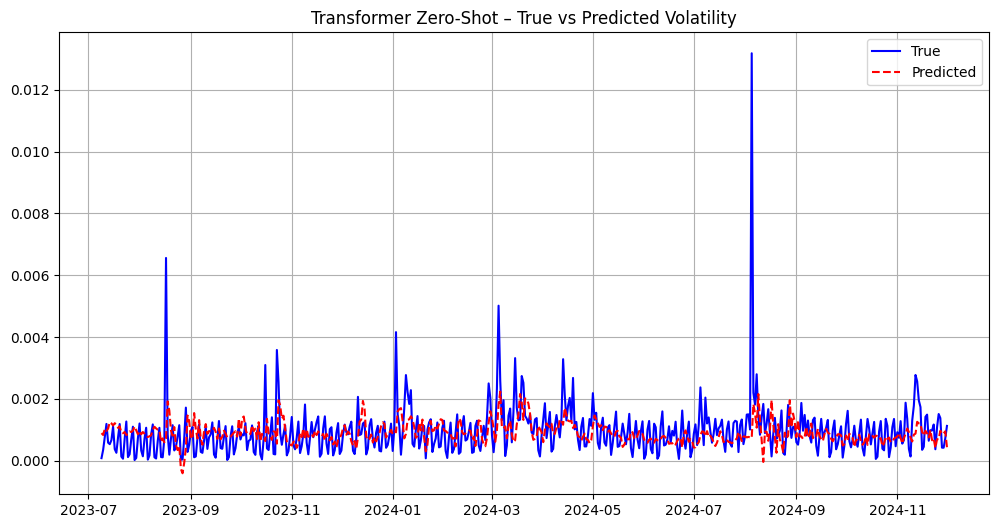

In [82]:
print("Avaliando modelo zero shot...")
forecast_dates_zeroshot, results_zeroshot = evaluate_and_visualize(model, test_ds, tsp, test_df, model_name="Transformer Zero-Shot")

Avaliando modelo fine-tuned...


c:\Users\Lenovo\Documents\GitHub\iniciacao-cientifica\venv\Lib\site-packages\torch\nn\modules\loss.py:535: UserWarning: Using a target size (torch.Size([32, 1, 1])) that is different to the input size (torch.Size([32, 96, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


=== AVALIAÇÃO FINAL – Transformer Fine-Tuned ===

MSE: 8.720049e-07
MAE: 5.642355e-04
RMSE: 9.338120e-04
MAPE: 9.176788e+01


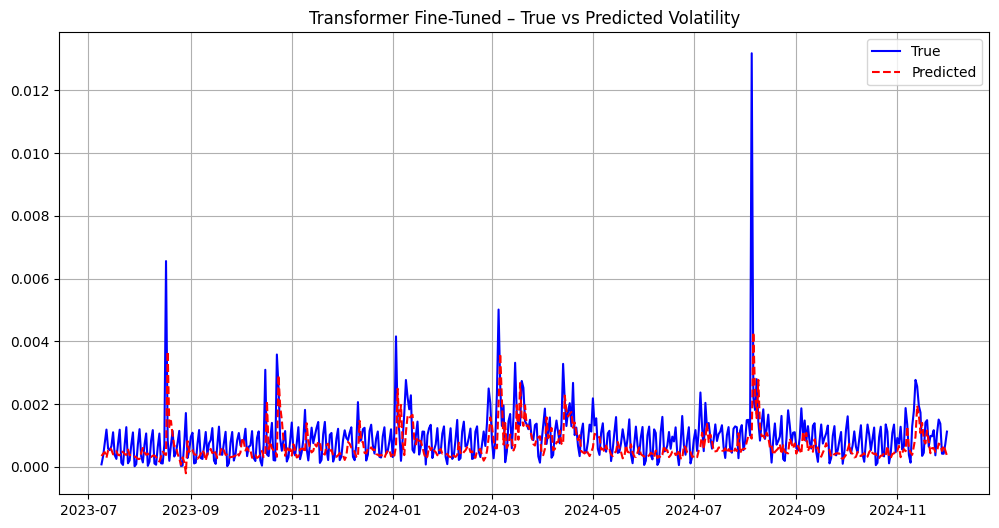

In [83]:
# ==================== AVALIAR MODELO TREINADO ====================
print("Avaliando modelo fine-tuned...")
forecast_dates_finetuned, results_finetuned = evaluate_and_visualize(model_ft, test_ds, tsp, test_df, model_name="Transformer Fine-Tuned")

In [84]:
# forecast_dates_scratch, results_scratch = evaluate_and_visualize(
#     model_scratch,
#     test_ds,
#     tsp,
#     test_df,
#     model_name="Transformer – From Scratch"
# )

Avaliando modelo HAR...

=== AVALIAÇÃO FINAL - LinearRegression (HAR) ===
TREINO:
  MSE: 1.869489e-05
  MAE: 1.370943e-03
  RMSE: 4.323759e-03
  MAPE: 1.144134e+02

TESTE:
  MSE: 9.469578e-07
  MAE: 5.646038e-04
  RMSE: 9.731175e-04
  MAPE: 2.387578e+02

Visualizando previsões no conjunto de teste...


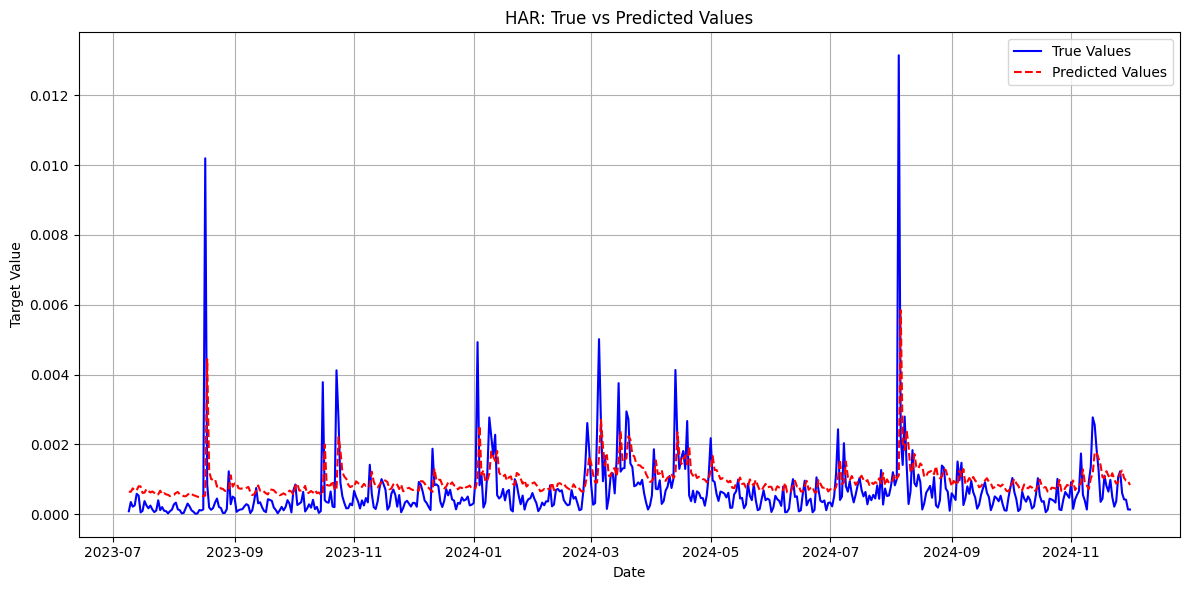

In [85]:
print("Avaliando modelo HAR...")
test_df = test_df[test_df[TIMESTAMP_COLUMN].isin(forecast_dates_zeroshot)]

features = ["Vol_lag_1", "Vol_week_mean", "Vol_month_mean"]

X_train = train_df[features].values
y_train = train_df[TARGET_COLUMN].values

X_test = test_df[features].values
y_test = test_df[TARGET_COLUMN].values
test_dates = test_df[TIMESTAMP_COLUMN].values

har = HarModel()
har.train(X_train, y_train)

y_pred_train = har.predict(X_train)
y_pred_test  = har.predict(X_test)

har.evaluate_and_visualize(
    y_train, y_pred_train,
    y_test, y_pred_test,
    test_dates=test_dates
)

Avaliando modelo HAR...

=== AVALIAÇÃO FINAL - LinearRegression (HAR) ===
TREINO:
  MSE: 1.869489e-05
  MAE: 1.370943e-03
  RMSE: 4.323759e-03
  MAPE: 1.144134e+02

TESTE:
  MSE: 9.469578e-07
  MAE: 5.646038e-04
  RMSE: 9.731175e-04
  MAPE: 2.387578e+02

Visualizando previsões no conjunto de teste...


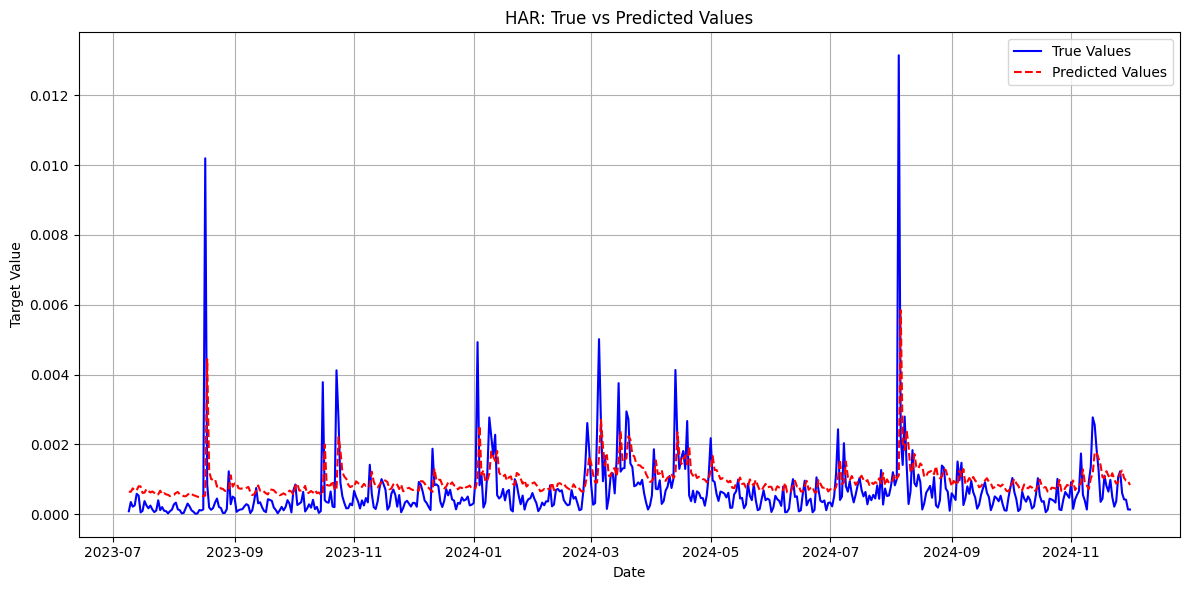

In [86]:
print("Avaliando modelo HAR...")
test_df = test_df[test_df[TIMESTAMP_COLUMN].isin(forecast_dates_finetuned)]

features = ["Vol_lag_1", "Vol_week_mean", "Vol_month_mean"]

X_train = train_df[features].values
y_train = train_df[TARGET_COLUMN].values

X_test = test_df[features].values
y_test = test_df[TARGET_COLUMN].values
test_dates = test_df[TIMESTAMP_COLUMN].values

har = HarModel()
har.train(X_train, y_train)

y_pred_train = har.predict(X_train)
y_pred_test  = har.predict(X_test)

har.evaluate_and_visualize(
    y_train, y_pred_train,
    y_test, y_pred_test,
    test_dates=test_dates
)